In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

party_colours = {
    'PDS': "purple",
    'DIE LINKE': "#BE3075",
    'SPD': "#E3000F",
    'GRÜNE': "#1AA037",
    'FDP':"#FFEF00",
    'CDU': "#000000",
    'CSU': "#0570C9",
    'AfD': "#5B3626",
    'OTHER': "grey"
}

## 1.1 Storing the data

In [2]:
# Accessing the XML file:
xml_path = './data_bundestag/mdb-data.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# Storing mdb data:
mdbs_data = []
for mdb in root.findall('MDB'):
    info = mdb.find('INFO')
    mdb = {
        'ID': info.findtext('ID'),
        'First_name': info.findtext('First_name'),
        'Last_name': info.findtext('Last_name'),
        'Acad_Title': info.findtext('Acad_Title'),
        'Date_of_birth': info.findtext('Date_of_birth'),
        'Gender': info.findtext('Gender'),
        'Party': info.findtext('Party'),
        'Marital_status': info.findtext('Marital_status'),
        'Children': info.findtext('Children'),
    }
    mdbs_data.append(mdb)
mdbs_df = pd.DataFrame(mdbs_data)

# Converting data types:
mdbs_df['ID'] = mdbs_df['ID'].astype(int)
mdbs_df['Date_of_birth'] = pd.to_datetime(mdbs_df['Date_of_birth'])
mdbs_df['Children'] = mdbs_df['Children'].astype(int)
mdbs_df['Gender'] = mdbs_df['Gender'].astype('category')
mdbs_df['Party'] = mdbs_df['Party'].astype('category')
mdbs_df['Marital_status'] = mdbs_df['Marital_status'].astype('category')
mdbs_df['Acad_Title'] = mdbs_df['Acad_Title']

# Storing wp data:
wp_data = []
for mdb in root.findall('MDB'):
    id = mdb.find('INFO').findtext('ID')
    wplist = mdb.find('WPLIST')
    for wp in wplist.findall('WP'):
        wp_entry = {
            'ID': int(id),
            'WP': int(wp.findtext('WP')),
            'MDBWP_FROM': wp.findtext('MDBWP_FROM'),
            'MDBWP_UNTIL': wp.findtext('MDBWP_UNTIL'),
            'WP_BEGIN': wp.findtext('WP_BEGIN'),
        }
        wp_data.append(wp_entry)
wp_df = pd.DataFrame(wp_data)

# Converting data types:
wp_df['MDBWP_FROM'] = pd.to_datetime(wp_df['MDBWP_FROM'])
wp_df['MDBWP_UNTIL'] = wp_df['MDBWP_UNTIL'].apply(
    lambda x: pd.to_datetime(x) if x != '/' else pd.NaT
)   # Handling open-ended dates (marked with "/").
wp_df['WP_BEGIN'] = pd.to_datetime(wp_df['WP_BEGIN'])

print("MDBs DataFrame:")
print(mdbs_df.info())
print("WPs DataFrame:")
print(wp_df.info())

MDBs DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 4614 entries, 0 to 4613
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              4614 non-null   int64         
 1   First_name      4614 non-null   str           
 2   Last_name       4614 non-null   str           
 3   Acad_Title      4614 non-null   str           
 4   Date_of_birth   4614 non-null   datetime64[us]
 5   Gender          4614 non-null   category      
 6   Party           4614 non-null   category      
 7   Marital_status  4614 non-null   category      
 8   Children        4614 non-null   int64         
dtypes: category(3), datetime64[us](1), int64(2), str(3)
memory usage: 230.0 KB
None
WPs DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 13046 entries, 0 to 13045
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ID           1304

## 1.2 Extracting and merging

In [3]:
# Creating a terms data frame:
terms_df = (
    wp_df[['WP', 'WP_BEGIN']]
    .drop_duplicates(subset='WP')
    .sort_values('WP_BEGIN')
    .reset_index(drop=True)
)
terms_df['election_y'] = terms_df['WP_BEGIN'].dt.year.astype(str)
    # Name election periods after the year they have begun.

# Merging wp_df and mdbs_df:
wp_df = wp_df.merge(mdbs_df, on='ID', how='left')

print("Terms DataFrame:")
print(terms_df.info())
print("WPs DataFrame:")
print(wp_df.info())

Terms DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   WP          21 non-null     int64         
 1   WP_BEGIN    21 non-null     datetime64[us]
 2   election_y  21 non-null     str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 636.0 bytes
None
WPs DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 13046 entries, 0 to 13045
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              13046 non-null  int64         
 1   WP              13046 non-null  int64         
 2   MDBWP_FROM      13046 non-null  datetime64[us]
 3   MDBWP_UNTIL     12416 non-null  datetime64[us]
 4   WP_BEGIN        13046 non-null  datetime64[us]
 5   First_name      13046 non-null  str           
 6   Last_name       13046 non-null  str        

## 2.1  Party composition per election period

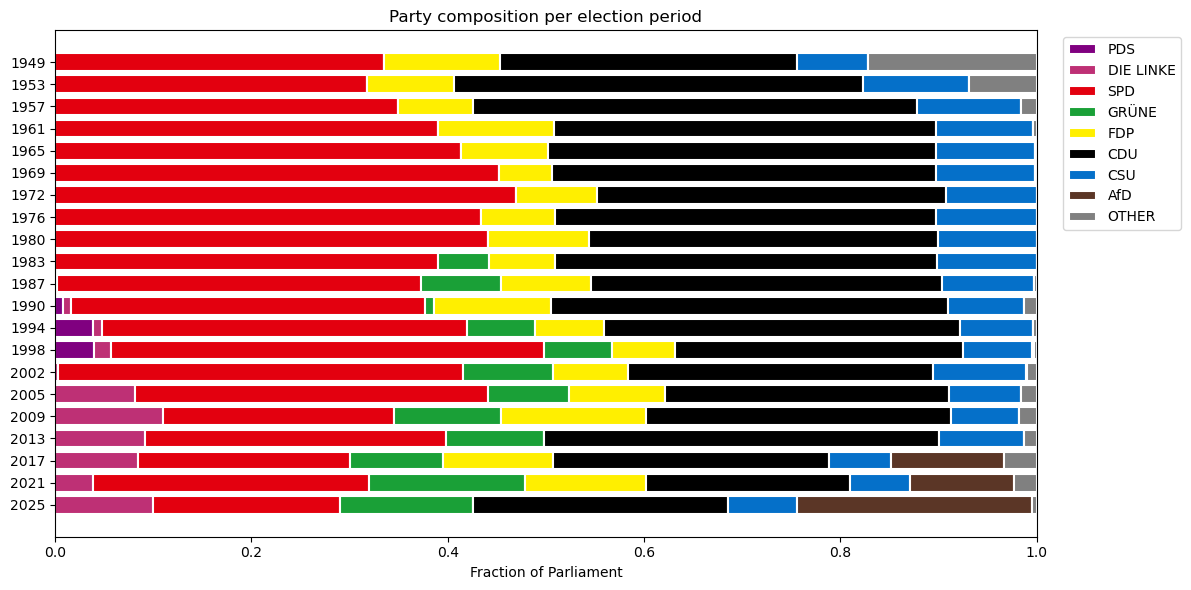

In [4]:
# Handling replacement members by calculating fraction of time served in parliament
# relative to the full election period:
terms_end_map = wp_df.dropna(subset=['MDBWP_UNTIL']).groupby('WP')['MDBWP_UNTIL'].max()
    # Use the latest observed `MDBWP_UNTIL` per WP as the period end, assuming that at least one MDB per WP finishes his term.
terms_end_map.loc[terms_df.loc[terms_df['WP_BEGIN'] == pd.Timestamp('2025-03-25'), 'WP'].iloc[0]] = pd.Timestamp('2026-07-17')
    # WP 21 uses 2026-07-17 (today) as the end date for fraction calculation.
terms_duration_map = (terms_end_map - terms_df.set_index('WP')['WP_BEGIN']).dt.days
    # Calculate duration of each term.
terms_end_dates = wp_df['WP'].map(terms_end_map)
wp_end_dates = wp_df['MDBWP_UNTIL'].fillna(terms_end_dates)
    # Handle open-ended terms.
wp_duration = (wp_end_dates - wp_df['MDBWP_FROM']).dt.days
    # Calculate total duration of each term.
wp_df['Frac_of_WP'] = (wp_duration / wp_df['WP'].map(terms_duration_map)).astype(float)

# Aggregate fractions per WP and party:
fractions = wp_df.groupby(['WP','Party'])['Frac_of_WP'].sum().unstack(fill_value=0)
    # Replace NaNs with 0.

# Normalize rows to 1:
fractions_norm = fractions.div(fractions.sum(axis=1).replace({0:1}), axis=0)
wps = fractions_norm.index.tolist()
y_pos = np.arange(len(wps))

# Plot as 100% stacked bar chart:
fig, ax = plt.subplots(figsize=(12, max(6, int(len(wps)*0.25))))
left = np.zeros(len(wps))
for party in party_colours.keys():
    vals = fractions_norm[party].values
    ax.barh(terms_df['election_y'], vals, left=left, color=party_colours.get(party), edgecolor='white', linewidth=1.5)
    left = left + vals
ax.set_xlabel('Fraction of Parliament')
ax.set_title('Party composition per election period')
ax.set_xlim(0,1)
ax.invert_yaxis()  # show earliest WP at the top
ax.legend(party_colours.keys(), bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# 3.0
def get_gender_ratio(group):
    gender_weight = (
    served_terms_df
    .groupby(group)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
    )

    male_share = gender_weight['male'] / gender_weight.sum(axis=1)
    gender_ratio = (-2 * (male_share - 0.5)).rename('gender_ratio').reset_index()
    return wp_df[['WP', 'name']].merge(gender_ratio, on='WP').sort_values('WP')

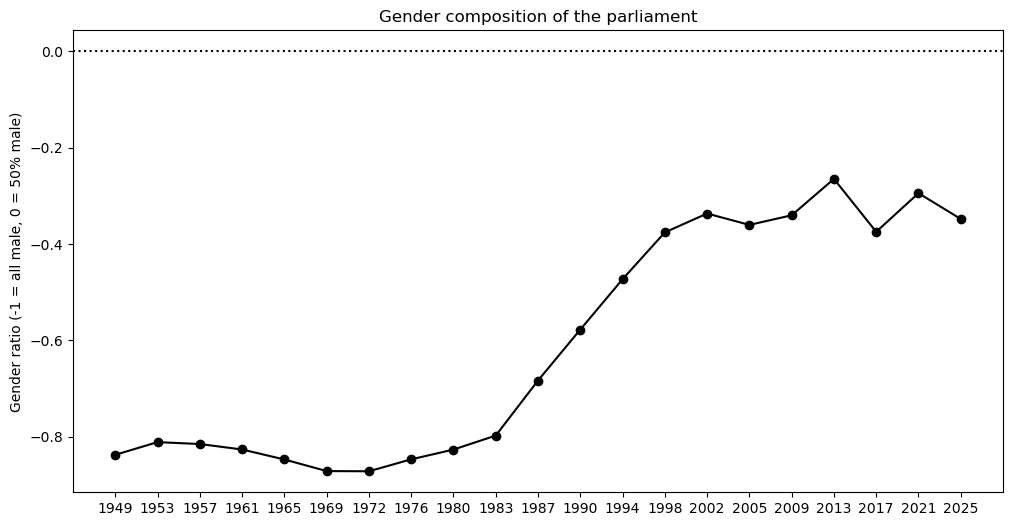

In [5]:
gender_ratio_overall_df = get_gender_ratio(['WP', 'Gender'])

fig, ax = plt.subplots(figsize=(12, max(6, int(len(gender_ratio_overall_df)*0.25))))
ax.axhline(0, color="black", linestyle=':')
ax.plot(gender_ratio_overall_df['name'], gender_ratio_overall_df['gender_ratio'], marker='o', color='black')
ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male)')
ax.set_title('Gender composition of the parliament')
plt.show()

In [6]:
gender_ratio_overall_df

,WP,name,gender_ratio
0,1,1949,-0.837250
1,2,1953,-0.810958
2,3,1957,-0.814914
3,4,1961,-0.826240
4,5,1965,-0.846972
5,6,1969,-0.871042
6,7,1972,-0.871453
7,8,1976,-0.846657
8,9,1980,-0.826386
9,10,1983,-0.797361


In [11]:
gender_ratio_by_party_df = get_gender_ratio(['WP', 'Party', 'Gender'])
gender_ratio_by_party_df = gender_ratio_by_party_df[~(
    (gender_ratio_by_party_df['Party'] == 'AfD')
    & (gender_ratio_by_party_df['name'].astype(int) < 2017)
)]  # No AfD in the parliament before 2017.
# This is a data inconsistency in the XML file where party membership is tied to mdb (ID) and not to an election term (WP).
# This allows mdbs to change their party membership in retrospective.
# Which obviously is neither possible nor a correct represention of votes.
# Party membership should be treated as a multikey time series object instead.
# But unfortunately, this cannot be fixed based on the irreparable information loss in the original data.
# We choose to manipulate the data where it is obviously wrong.
# However, it is likely that more such inconsistencies exist.
# Without specific membership data per WP quick fixes like the above remain inaccurate.

(131, 4)
   WP  name  Party  gender_ratio
0   1  1949    CDU     -0.817585
1   1  1949    CSU     -0.932685
2   1  1949    FDP     -0.903608
3   1  1949  OTHER     -0.906479
4   1  1949    SPD     -0.775584
     WP  name      Party  gender_ratio
126  21  2025        CSU     -0.500000
127  21  2025  DIE LINKE      0.166092
128  21  2025      GRÜNE      0.239211
129  21  2025      OTHER     -1.000000
130  21  2025        SPD     -0.166536
<class 'pandas.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   WP            131 non-null    int64   
 1   name          131 non-null    str     
 2   Party         131 non-null    category
 3   gender_ratio  131 non-null    float64 
dtypes: category(1), float64(1), int64(1), str(1)
memory usage: 3.7 KB
None
               WP  gender_ratio
count  131.000000    131.000000
mean    12.083969     -0.521400
std      5.930415      0.41499

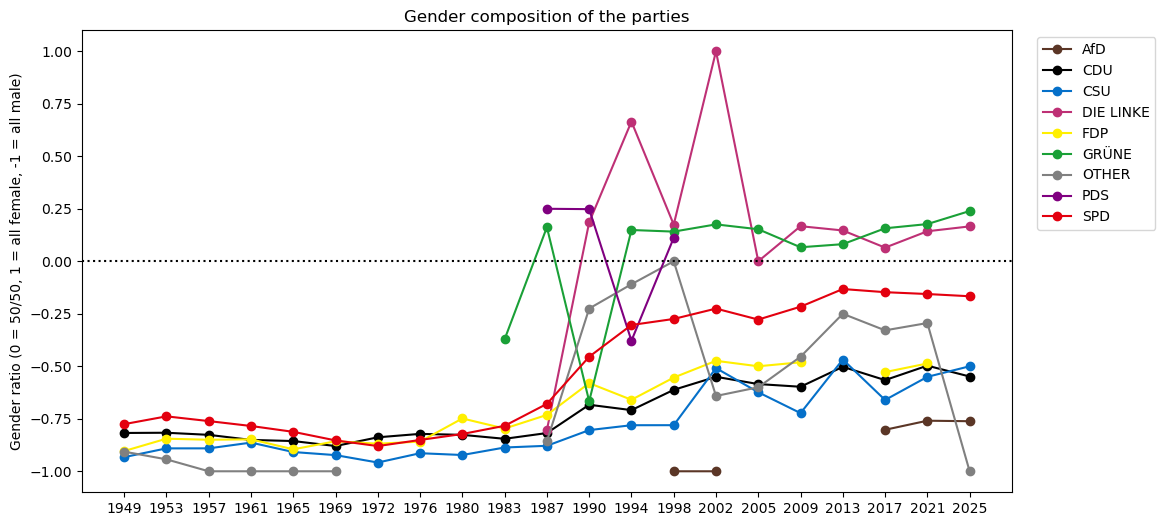

In [7]:
p_df = get_gender_ratio(['WP', 'Party', 'Gender'])

# No AfD in the parliament before 2017.
# Full ordered list of WPs/names, so gaps become NaN instead of being skipped over
full_wp_order = wp_df[['WP', 'name']].sort_values('WP').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, max(6, int(full_wp_order.shape[0] * 0.25))))

for party, group in p_df.groupby('Party'):
    # Reindex to the full WP range; missing WPs become NaN and break the line
    group_full = (
        full_wp_order
        .merge(group[['WP', 'gender_ratio']], on='WP', how='left')
    )
    ax.plot(
        group_full['name'],
        group_full['gender_ratio'],
        marker='o',
        label=party,
        color=party_colours.get(party, 'grey')
    )

ax.set_ylabel('Gender ratio (0 = 50/50, 1 = all female, -1 = all male)')
ax.set_xlabel('')
ax.set_title('Gender composition of the parties')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='black', linestyle=':')
plt.show()

In [8]:
served_terms_df

,ID,WP,MDBWP_FROM,MDBWP_UNTIL,WP_BEGIN,Frac_of_WP,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,5,1965-10-19,1969-10-19,1965-10-19,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000001,6,1969-10-20,1972-09-22,1969-10-20,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
2,11000001,7,1972-12-13,1976-12-13,1972-12-13,0.999316,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
3,11000001,8,1976-12-14,1980-11-04,1976-12-14,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
4,11000001,9,1980-11-04,1983-03-29,1980-11-04,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13041,11005623,21,2025-06-10,NaT,2025-03-25,0.839248,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
13042,11005624,21,2025-07-01,NaT,2025-03-25,0.795407,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
13043,11005625,21,2025-08-01,NaT,2025-03-25,0.730689,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
13044,11005626,21,2025-09-01,NaT,2025-03-25,0.665971,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


In [12]:
wp_df

,WP,WP_BEGIN,name
0,1,1949-09-07,1949
1,2,1953-10-06,1953
2,3,1957-10-15,1957
3,4,1961-10-17,1961
4,5,1965-10-19,1965
5,6,1969-10-20,1969
6,7,1972-12-13,1972
7,8,1976-12-14,1976
8,9,1980-11-04,1980
9,10,1983-03-29,1983
